<a href="https://colab.research.google.com/github/brandim04/AnaliseDeDados/blob/main/Aula_Visualiza%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desafios de Visualização de Dados**

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações padrão para gráficos (para começar limpo)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

Bibliotecas importadas e configurações aplicadas!


### 1: Desafios de Decisão

Para cada cenário abaixo, você receberá um conjunto de dados e uma pergunta de negócio. Sua tarefa é:

1. Analisar a pergunta e o tipo de dado.

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

Desafio 1.1: Comparação de Vendas por Região

Cenário: Uma empresa de varejo quer comparar o desempenho de vendas de suas quatro regiões no último trimestre para identificar qual delas precisa de mais atenção.



In [2]:
# Dados para o Desafio 1.1
dados_regiao = {
    'Regiao': ['Norte', 'Sul', 'Leste', 'Oeste'],
    'Vendas_Milhoes': [12.5, 18.2, 15.0, 9.8]
}
df_regiao = pd.DataFrame(dados_regiao)
print("\nDataFrame para Desafio 1.1:")
print(df_regiao)


DataFrame para Desafio 1.1:
  Regiao  Vendas_Milhoes
0  Norte            12.5
1    Sul            18.2
2  Leste            15.0
3  Oeste             9.8


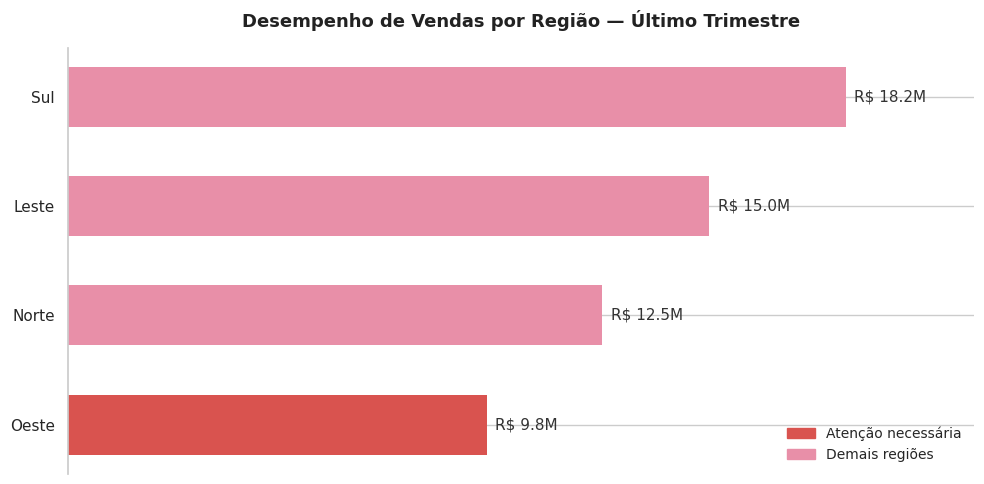

In [23]:
# 1. Tipo de gráfico escolhido: Barras horizontais
# 2. Justificativa:
#    - Escolhi horizontal porque os nomes das regiões ficam mais legíveis
#    - Pelo princípio de Cleveland-McGill, barras permitem comparar valores pelo comprimento,
#      que é uma das formas mais fáceis pro olho humano perceber diferença
#    - Ordenei do menor pro maior pra deixar óbvio quem tá ficando pra trás (Oeste)
#    - Destaquei em vermelho a região com menor venda, Gestalt de destaque, chama atenção
#    - Tirei o eixo X e coloquei os valores direto nas barras pra não ter leitura dupla

df_regiao_sorted = df_regiao.sort_values('Vendas_Milhoes')

cores = ['#d9534f' if v == df_regiao_sorted['Vendas_Milhoes'].min() else '#e88fa8'
         for v in df_regiao_sorted['Vendas_Milhoes']]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(df_regiao_sorted['Regiao'], df_regiao_sorted['Vendas_Milhoes'],
               color=cores, edgecolor='none', height=0.55)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2,
            f'R$ {width:.1f}M', va='center', ha='left', fontsize=11, color='#333333')

ax.set_title('Desempenho de Vendas por Região — Último Trimestre',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlim(0, df_regiao_sorted['Vendas_Milhoes'].max() + 3)
ax.tick_params(axis='y', labelsize=11)
ax.xaxis.set_visible(False)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legenda = [Patch(color='#d9534f', label='Atenção necessária'),
           Patch(color='#e88fa8', label='Demais regiões')]
ax.legend(handles=legenda, loc='lower right', frameon=False, fontsize=10)

sns.despine(left=False, bottom=True, ax=ax)
plt.tight_layout()
plt.show()

Desafio 1.2: Distribuição de Idades de Clientes

Cenário: Uma equipe de marketing quer entender a distribuição de idade de seus clientes para segmentar campanhas. Eles têm dados de idade de 1000 clientes.

In [7]:
# Dados para o Desafio 1.2
np.random.seed(42)
idades = np.random.normal(loc=35, scale=10, size=1000).astype(int)
idades = idades[(idades >= 18) & (idades <= 70)] # Limitar idades razoáveis
df_idades = pd.DataFrame({'Idade': idades})
print("\nDataFrame para Desafio 1.2 (primeiras 5 linhas):")
print(df_idades.head())


DataFrame para Desafio 1.2 (primeiras 5 linhas):
   Idade
0     39
1     33
2     41
3     50
4     32


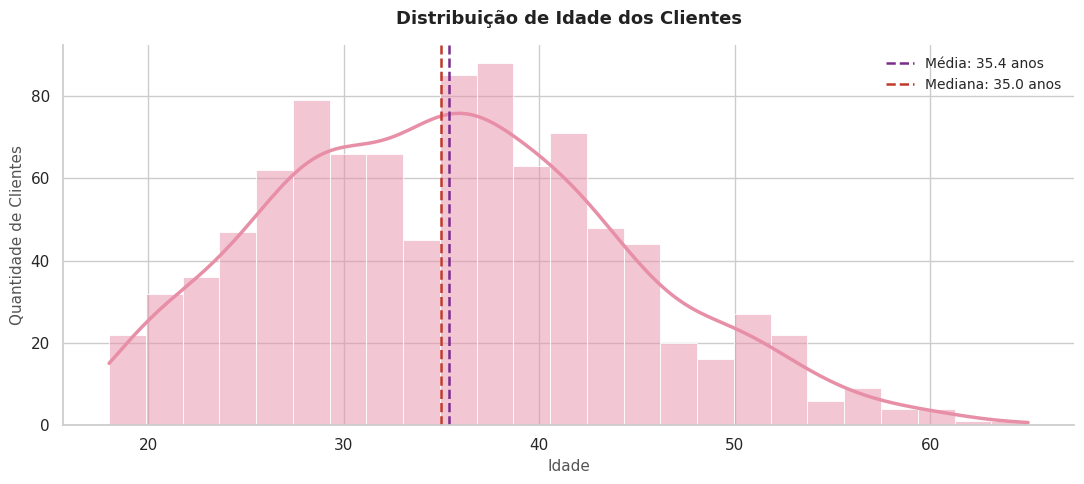

In [24]:
# 1. Tipo de gráfico escolhido: Histograma com curva KDE
# 2. Justificativa:
#    - Histograma é o mais direto pra ver distribuição de uma variável contínua como idade
#    - Adicionei a curva KDE em cima pra suavizar e facilitar a leitura do formato geral
#      (onde tá o pico, se é simétrico, se tem cauda)
#    - Pelo princípio de Tufte, evitei grade pesada e bordas desnecessárias
#    - Adicionei linhas de média e mediana pra dar contexto estatístico sem precisar de tabela
#    - A cor única e sem variação segue Gestalt de similaridade, todos os bins são a mesma
#      coisa, então não faz sentido diferenciar

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(df_idades['Idade'], bins=25, kde=True, ax=ax,
             color='#e88fa8', edgecolor='white', linewidth=0.6,
             line_kws={'linewidth': 2.5, 'color': '#b5446e'})

media = df_idades['Idade'].mean()
mediana = df_idades['Idade'].median()

ax.axvline(media, color='#7b2d8b', linestyle='--', linewidth=1.8, label=f'Média: {media:.1f} anos')
ax.axvline(mediana, color='#c0392b', linestyle='--', linewidth=1.8, label=f'Mediana: {mediana:.1f} anos')

ax.set_title('Distribuição de Idade dos Clientes', fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Idade', fontsize=11, color='#555555')
ax.set_ylabel('Quantidade de Clientes', fontsize=11, color='#555555')
ax.legend(frameon=False, fontsize=10)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Desafio 1.3: Tendência de Acessos ao Site

Cenário: A equipe de produto quer monitorar a evolução diária do número de acessos ao site nos últimos 30 dias para identificar padrões ou quedas.

In [9]:
# Dados para o Desafio 1.3
datas = pd.date_range(start='2024-03-01', periods=30)
np.random.seed(42)
acessos = np.random.randint(1000, 5000, 30)
# Simular uma queda nos últimos dias
acessos[-5:] = np.random.randint(500, 1500, 5)
df_acessos = pd.DataFrame({'Data': datas, 'Acessos': acessos})
print("\nDataFrame para Desafio 1.3 (primeiras 5 linhas):")
print(df_acessos.head())


DataFrame para Desafio 1.3 (primeiras 5 linhas):
        Data  Acessos
0 2024-03-01     4174
1 2024-03-02     4507
2 2024-03-03     1860
3 2024-03-04     2294
4 2024-03-05     2130


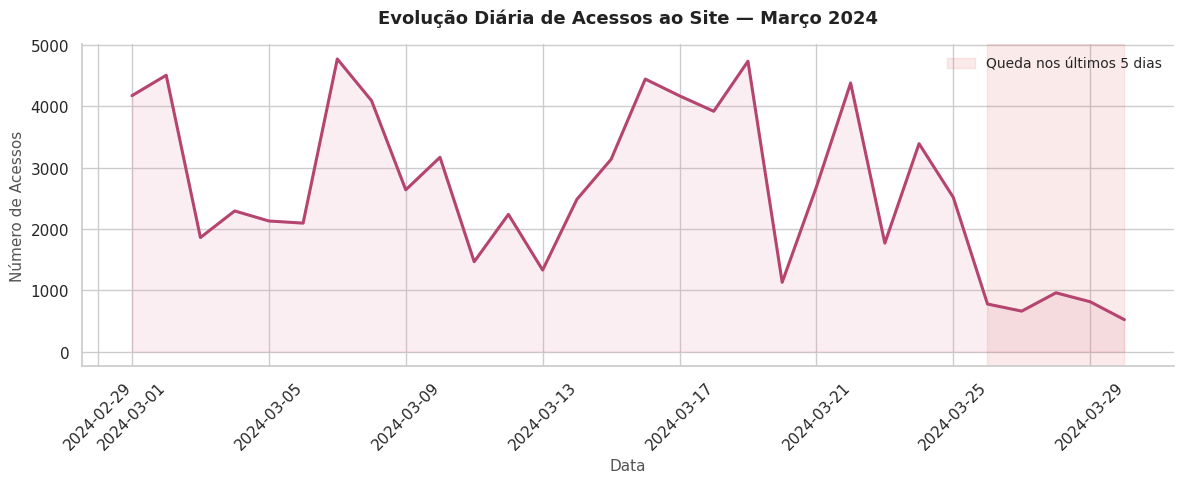

In [10]:
# 1. Tipo de gráfico escolhido: Gráfico de linha
# 2. Justificativa:
#    - Dado temporal = linha
#    - Cleveland-McGill: posição ao longo do eixo Y deixa fácil ver a magnitude da queda
#    - Gestalt de continuidade: a linha conecta os pontos e deixa o padrão geral mais legível
#      do que barras dia a dia fariam
#    - Destaquei a zona de queda com fundo vermelho

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df_acessos['Data'], df_acessos['Acessos'],
                alpha=0.15, color='#e88fa8')

sns.lineplot(data=df_acessos, x='Data', y='Acessos', ax=ax,
             color='#b5446e', linewidth=2.2)

ax.axvspan(df_acessos['Data'].iloc[-5], df_acessos['Data'].iloc[-1],
           alpha=0.12, color='#d9534f', label='Queda nos últimos 5 dias')

ax.set_title('Evolução Diária de Acessos ao Site — Março 2024',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Data', fontsize=11, color='#555555')
ax.set_ylabel('Número de Acessos', fontsize=11, color='#555555')
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False, fontsize=10)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Desafio 1.4: Relação entre Investimento em Marketing e Vendas

Cenário: A equipe de finanças quer entender se há uma correlação entre o investimento mensal em marketing e o volume de vendas gerado no mesmo mês.

In [11]:
# Dados para o Desafio 1.4
np.random.seed(42)
investimento_marketing = np.random.randint(10000, 50000, 12)
vendas_mensais = investimento_marketing * 5 + np.random.randint(-5000, 5000, 12)
df_marketing_vendas = pd.DataFrame({
    'Investimento_Marketing': investimento_marketing,
    'Vendas_Mensais': vendas_mensais
})
print("\nDataFrame para Desafio 1.4 (primeiras 5 linhas):")
print(df_marketing_vendas.head())


DataFrame para Desafio 1.4 (primeiras 5 linhas):
   Investimento_Marketing  Vendas_Mensais
0                   25795          129286
1                   10860           54351
2                   48158          242210
3                   21284          102604
4                   16265           80880


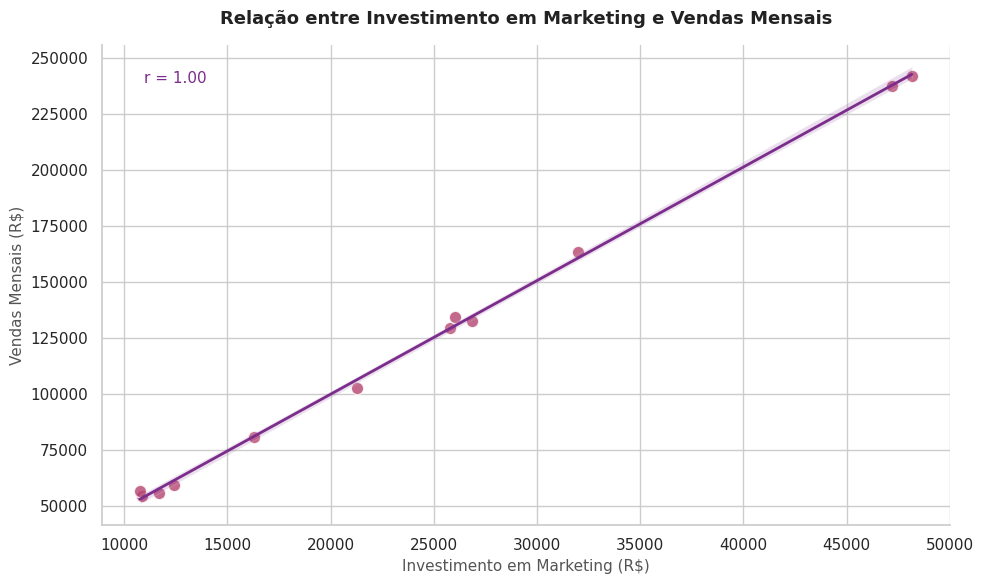

In [25]:
# 1. Tipo de gráfico escolhido: Scatter plot com linha de regressão
# 2. Justificativa:
#    - A pergunta é sobre correlação entre duas variáveis numéricas, entaoscatter é o mais direto
#    - A linha de regressão ajuda a confirmar visualmente se a relação é positiva, negativa
#      ou inexistente, sem precisar calcular nada separado
#    - Cleveland-McGill: posição em dois eixos é uma das formas mais precisas de comparar
#      duas quantidades ao mesmo tempo
#    - Gestalt de proximidade: pontos agrupados perto da linha mostram que a correlação é forte

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(data=df_marketing_vendas, x='Investimento_Marketing', y='Vendas_Mensais',
            ax=ax, scatter_kws={'color': '#b5446e', 'edgecolor': 'white', 's': 80},
            line_kws={'color': '#7b2d8b', 'linewidth': 2},
            ci=95)

ax.set_title('Relação entre Investimento em Marketing e Vendas Mensais',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Investimento em Marketing (R$)', fontsize=11, color='#555555')
ax.set_ylabel('Vendas Mensais (R$)', fontsize=11, color='#555555')

corr = df_marketing_vendas['Investimento_Marketing'].corr(df_marketing_vendas['Vendas_Mensais'])
ax.text(0.05, 0.92, f'r = {corr:.2f}', transform=ax.transAxes,
        fontsize=11, color='#7b2d8b')

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Desafio 1.5: Composição de Mercado por Categoria de Produto

Cenário: Um analista de mercado quer visualizar a proporção de cada categoria de produto no total de vendas da empresa para entender a dominância de certas categorias.

In [13]:
# Dados para o Desafio 1.5
dados_categorias = {
    'Categoria': ['Eletrônicos', 'Vestuário', 'Alimentos', 'Livros', 'Serviços'],
    'Vendas_Milhoes': [35.0, 20.0, 15.0, 10.0, 5.0]
}
df_categorias = pd.DataFrame(dados_categorias)
print("\nDataFrame para Desafio 1.5:")
print(df_categorias)


DataFrame para Desafio 1.5:
     Categoria  Vendas_Milhoes
0  Eletrônicos            35.0
1    Vestuário            20.0
2    Alimentos            15.0
3       Livros            10.0
4     Serviços             5.0


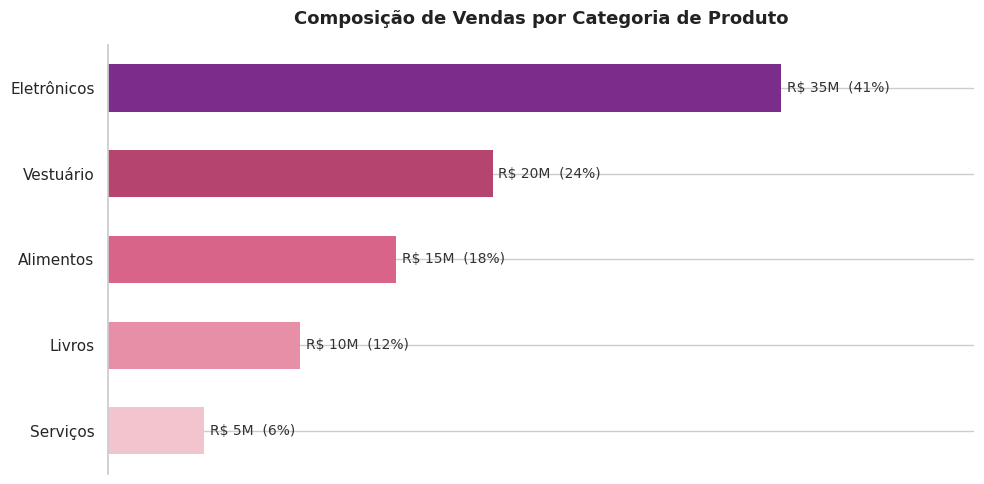

In [14]:
# 1. Tipo de gráfico escolhido: Gráfico de barras horizontais
# 2. Justificativa:
#    - Cleveland-McGill mostra que comparar ângulos é muito menos preciso do que comparar comprimentos
#    - Com barras ordenadas dá pra ver de cara a dominância dos Eletrônicos e a participação
#      de cada categoria sem esforço
#    - Adicionei o percentual direto nas barras pra não precisar de legenda separada
#    - Gestalt de ordem: ordenar do maior pro menor guia o olho naturalmente

total = df_categorias['Vendas_Milhoes'].sum()
df_categorias['Percentual'] = df_categorias['Vendas_Milhoes'] / total * 100
df_sorted = df_categorias.sort_values('Vendas_Milhoes')

cores = ['#f2c4ce', '#e88fa8', '#d9648a', '#b5446e', '#7b2d8b']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(df_sorted['Categoria'], df_sorted['Vendas_Milhoes'],
               color=cores, edgecolor='none', height=0.55)

for bar, (_, row) in zip(bars, df_sorted.iterrows()):
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height() / 2,
            f'R$ {width:.0f}M  ({row["Percentual"]:.0f}%)',
            va='center', ha='left', fontsize=10, color='#333333')

ax.set_title('Composição de Vendas por Categoria de Produto',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlim(0, df_sorted['Vendas_Milhoes'].max() + 10)
ax.tick_params(axis='y', labelsize=11)
ax.xaxis.set_visible(False)

sns.despine(left=False, bottom=True, ax=ax)
plt.tight_layout()
plt.show()

### Parte 2: Desafios de Refatoração Crítica

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1: Vendas Trimestrais com Eixo Y Enganoso

Cenário: Um gerente de vendas recebeu este gráfico e está preocupado com uma suposta queda drástica nas vendas do Q4.

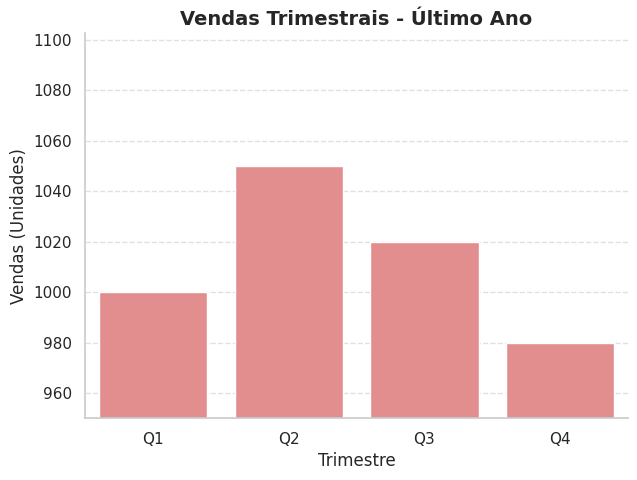

In [15]:
# Dados para o Desafio 2.1
dados_trimestrais = {
    'Trimestre': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Vendas': [1000, 1050, 1020, 980]
}
df_trimestral = pd.DataFrame(dados_trimestrais)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral, color='lightcoral')
ax.set_ylim(bottom=950) # Eixo Y começando alto
ax.set_title('Vendas Trimestrais - Último Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Vendas (Unidades)')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_1303/1100587058.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral,


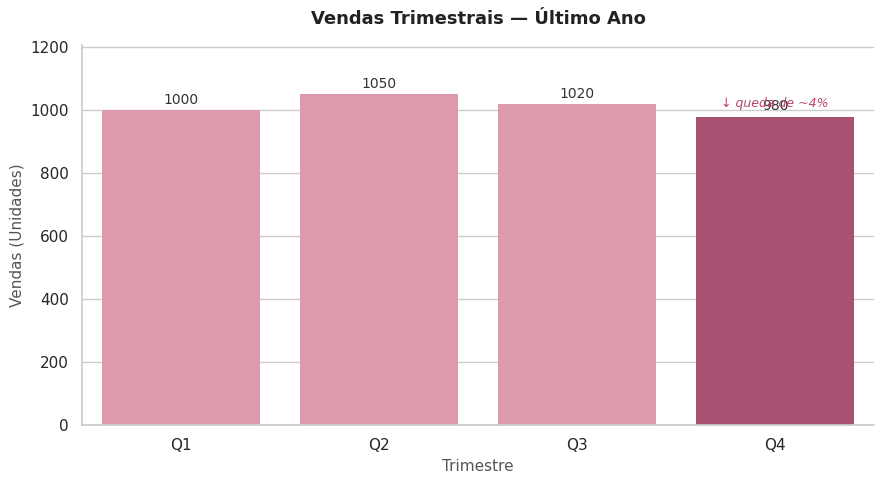

In [22]:
# 1. Problemas identificados:
#    a) Lie Factor (Tufte): eixo Y começa em 950 em vez de 0, fazendo a diferença entre
#       Q3 e Q4 parecer enorme quando na real é de apenas 40 unidades (~4%)
#    b) Chartjunk: grade desnecessária competindo com as barras sem agregar informação
#    c) Gestalt (similaridade): todas as barras na mesma cor não ajudam a destacar nada,
#       mas o eixo truncado já cria uma percepção falsa de destaque no Q4
#    d) Cleveland-McGill: barras são eficazes pra comparação por comprimento, mas com o
#       eixo truncado essa codificação fica completamente corrompida

# 2. Código refatorado:

fig, ax = plt.subplots(figsize=(9, 5))

cores = ['#e88fa8' if t != 'Q4' else '#b5446e' for t in df_trimestral['Trimestre']]

sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral,
            palette=cores, ax=ax, edgecolor='none')

ax.set_ylim(0, df_trimestral['Vendas'].max() * 1.15)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 10,
            f'{int(p.get_height())}', ha='center', va='bottom',
            fontsize=10, color='#333333')

ax.set_title('Vendas Trimestrais — Último Ano', fontsize=13,
             fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Trimestre', fontsize=11, color='#555555')
ax.set_ylabel('Vendas (Unidades)', fontsize=11, color='#555555')

ax.text(3, 980 + 30, '↓ queda de ~4%', ha='center', fontsize=9,
        color='#b5446e', style='italic')

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Desafio 2.2: Comparação de Produtos com Gráfico de Pizza Lotado

Cenário: A equipe de produto quer ver a proporção de vendas de 8 produtos diferentes, mas o gráfico atual está confuso.

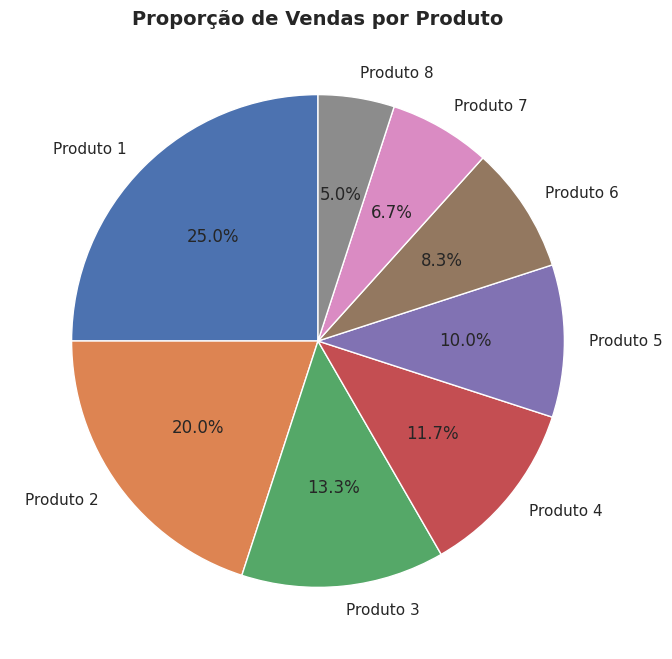

In [17]:
# Dados para o Desafio 2.2
dados_produtos = {
    'Produto': [f'Produto {i}' for i in range(1, 9)],
    'Vendas': [150, 120, 80, 70, 60, 50, 40, 30]
}
df_produtos = pd.DataFrame(dados_produtos)

plt.figure(figsize=(8, 8))
plt.pie(df_produtos['Vendas'], labels=df_produtos['Produto'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Vendas por Produto', fontsize=14, fontweight='bold')
plt.show()

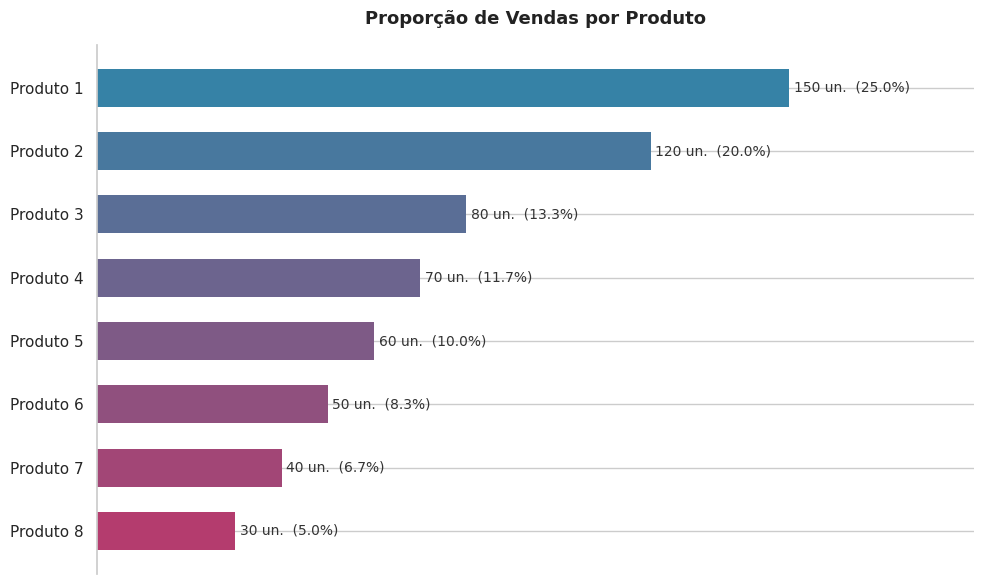

In [18]:
# 1. Problemas identificados:
#    a) Cleveland-McGill: pizza exige comparação por ângulo e área, que são as formas
#       menos precisas de percepção visual, com 8 fatias fica impossível saber qual é
#       maior sem olhar o número
#    b) Chartjunk (Tufte): rótulos + percentuais em cima das fatias criam poluição visual,
#       especialmente nas fatias menores onde tudo se sobrepõe
#    c) Gestalt (similaridade): 8 cores diferentes sem critério dão a impressão de que
#       cada produto é igualmente importante, quando na real há uma diferença grande
#       entre Produto 1 (150) e Produto 8 (30)

# 2. Código refatorado — trocando pizza por barras horizontais:

total = df_produtos['Vendas'].sum()
df_produtos['Percentual'] = df_produtos['Vendas'] / total * 100
df_sorted = df_produtos.sort_values('Vendas')

cores = [f'#{int(180 - i*18):02x}{int(60 + i*10):02x}{int(110 + i*8):02x}'
         for i in range(len(df_sorted))]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_sorted['Produto'], df_sorted['Vendas'],
               color=cores, edgecolor='none', height=0.6)

for bar, (_, row) in zip(bars, df_sorted.iterrows()):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height() / 2,
            f'{int(width)} un.  ({row["Percentual"]:.1f}%)',
            va='center', ha='left', fontsize=10, color='#333333')

ax.set_title('Proporção de Vendas por Produto',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlim(0, df_sorted['Vendas'].max() + 40)
ax.tick_params(axis='y', labelsize=11)
ax.xaxis.set_visible(False)

sns.despine(left=False, bottom=True, ax=ax)
plt.tight_layout()
plt.show()

Desafio 2.3: Desempenho de Funcionários com Cores Aleatórias

Cenário: O RH quer visualizar o desempenho (pontuação de 0 a 100) de 5 funcionários em uma avaliação, mas o gráfico atual usa cores sem sentido.

/tmp/ipykernel_1303/178950125.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)


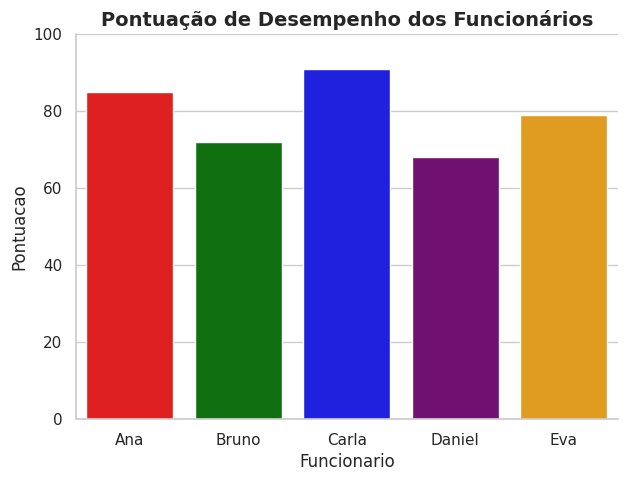

In [20]:
# Dados para o Desafio 2.3
dados_funcionarios = {
    'Funcionario': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Pontuacao': [85, 72, 91, 68, 79]
}
df_funcionarios = pd.DataFrame(dados_funcionarios)

plt.figure(figsize=(7, 5))
cores_aleatorias = ['red', 'green', 'blue', 'purple', 'orange']
ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)
ax.set_title('Pontuação de Desempenho dos Funcionários', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
plt.show()

/tmp/ipykernel_1303/103635176.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Funcionario', y='Pontuacao', data=df_sorted,


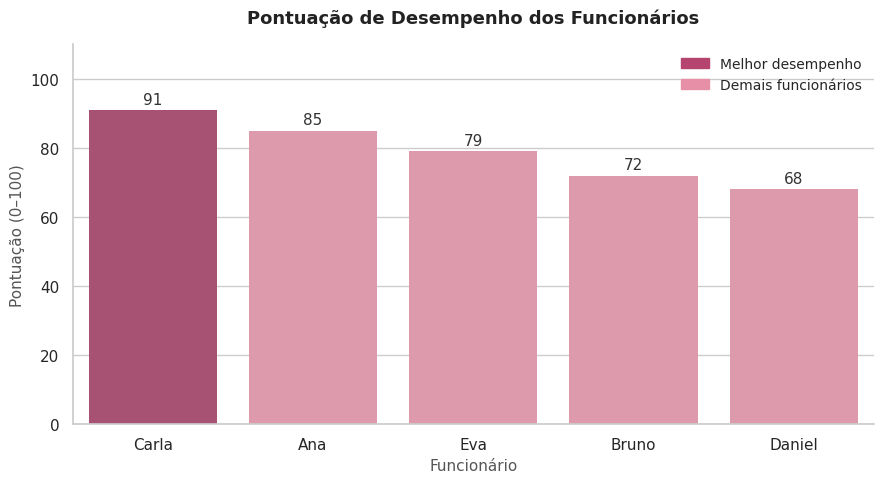

In [21]:
# 1. Problemas identificados:
#    a) Gestalt (similaridade): cores diferentes pra cada funcionário sugere que cada um
#       pertence a uma categoria distinta
#    b) Tufte (Data-Ink Ratio): as cores vibrantes e variadas são puro chartjunk, não
#       adicionam nenhuma informação e ainda distraem da comparação principal
#    c) Cleveland-McGill: sem rótulos de valor nas barras, o leitor precisa ficar indo
#       e voltando pro eixo Y pra estimar cada pontuação

# 2. Código refatorado:

df_sorted = df_funcionarios.sort_values('Pontuacao', ascending=False)

cores = ['#b5446e' if p == df_sorted['Pontuacao'].max() else '#e88fa8'
         for p in df_sorted['Pontuacao']]

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(x='Funcionario', y='Pontuacao', data=df_sorted,
            palette=cores, ax=ax, edgecolor='none', order=df_sorted['Funcionario'])

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 1,
            f'{int(p.get_height())}', ha='center', va='bottom',
            fontsize=11, color='#333333')

ax.set_ylim(0, 110)
ax.set_title('Pontuação de Desempenho dos Funcionários',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Funcionário', fontsize=11, color='#555555')
ax.set_ylabel('Pontuação (0–100)', fontsize=11, color='#555555')

from matplotlib.patches import Patch
legenda = [Patch(color='#b5446e', label='Melhor desempenho'),
           Patch(color='#e88fa8', label='Demais funcionários')]
ax.legend(handles=legenda, frameon=False, fontsize=10)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Desafio 2.4: Gráfico de Linhas com Chartjunk Excessivo

Cenário: Um analista de dados criou este gráfico para mostrar a evolução de duas métricas ao longo do tempo, mas ele está muito poluído.

/tmp/ipykernel_1303/3038338850.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')


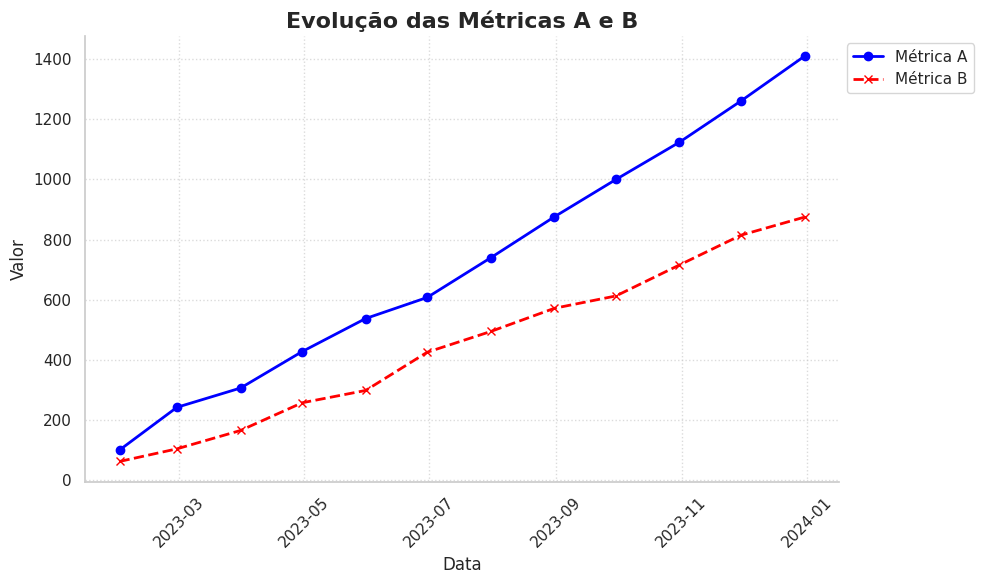

In [26]:
# Dados para o Desafio 2.4
datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')
np.random.seed(42)
metrica_a = np.random.randint(50, 150, 12).cumsum()
metrica_b = np.random.randint(40, 130, 12).cumsum()

df_metricas = pd.DataFrame({
    'Data': datas_mes,
    'Metrica_A': metrica_a,
    'Metrica_B': metrica_b
})

plt.figure(figsize=(10, 6))
plt.plot(df_metricas['Data'], df_metricas['Metrica_A'], label='Métrica A', marker='o', linestyle='-', linewidth=2, color='blue')
plt.plot(df_metricas['Data'], df_metricas['Metrica_B'], label='Métrica B', marker='x', linestyle='--', linewidth=2, color='red')

plt.title('Evolução das Métricas A e B', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

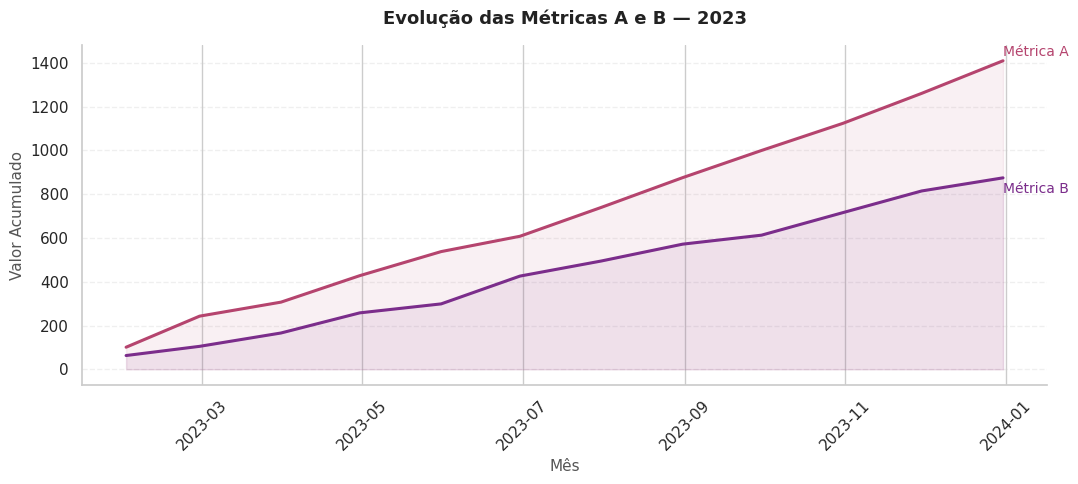

In [27]:
# 1. Problemas identificados:
#    a) Chartjunk (Tufte): grade cheia com linhas pontilhadas em todo o gráfico polui
#       sem agregar
#    b) Gestalt (proximidade): legenda jogada pra fora do gráfico com bbox_to_anchor
#       quebra a proximidade com os elementos que ela descreve
#    c) Tufte (Data-Ink Ratio): marcadores em todo ponto (o + x) aumentam a tinta
#       sem necessidade

# 2. Código refatorado:

fig, ax = plt.subplots(figsize=(11, 5))

ax.fill_between(df_metricas['Data'], df_metricas['Metrica_A'], alpha=0.08, color='#b5446e')
ax.fill_between(df_metricas['Data'], df_metricas['Metrica_B'], alpha=0.08, color='#7b2d8b')

ax.plot(df_metricas['Data'], df_metricas['Metrica_A'],
        color='#b5446e', linewidth=2.2, label='Métrica A')
ax.plot(df_metricas['Data'], df_metricas['Metrica_B'],
        color='#7b2d8b', linewidth=2.2, label='Métrica B')

ax.text(df_metricas['Data'].iloc[-1], df_metricas['Metrica_A'].iloc[-1] + 10,
        'Métrica A', color='#b5446e', fontsize=10, va='bottom')
ax.text(df_metricas['Data'].iloc[-1], df_metricas['Metrica_B'].iloc[-1] - 20,
        'Métrica B', color='#7b2d8b', fontsize=10, va='top')

ax.set_title('Evolução das Métricas A e B — 2023',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Mês', fontsize=11, color='#555555')
ax.set_ylabel('Valor Acumulado', fontsize=11, color='#555555')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Desafio 2.5: Comparação de Desempenho com Gráfico de Bolhas Confuso

Cenário: Um gerente de produto quer comparar o desempenho de diferentes funcionalidades (Funcionalidade 1 a 5) com base em duas métricas: 'Uso' e 'Satisfação'. O tamanho da bolha representa o 'Impacto'.

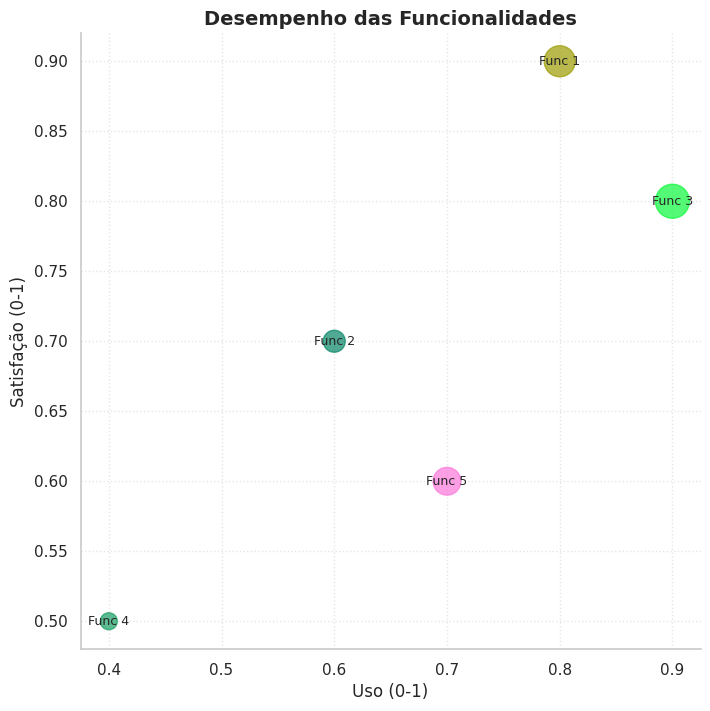

In [28]:
# Dados para o Desafio 2.5
dados_funcionalidades = {
    'Funcionalidade': [f'Func {i}' for i in range(1, 6)],
    'Uso': [0.8, 0.6, 0.9, 0.4, 0.7],
    'Satisfacao': [0.9, 0.7, 0.8, 0.5, 0.6],
    'Impacto': [100, 50, 120, 30, 80]
}
df_funcionalidades = pd.DataFrame(dados_funcionalidades)

plt.figure(figsize=(8, 8))
plt.scatter(x=df_funcionalidades['Uso'], y=df_funcionalidades['Satisfacao'],
            s=df_funcionalidades['Impacto']*5, # Multiplicar para bolhas maiores
            alpha=0.7,
            c=np.random.rand(len(df_funcionalidades), 3)) # Cores aleatórias

for i, row in df_funcionalidades.iterrows():
    plt.text(row['Uso'], row['Satisfacao'], row['Funcionalidade'], fontsize=9, ha='center', va='center')

plt.title('Desempenho das Funcionalidades', fontsize=14, fontweight='bold')
plt.xlabel('Uso (0-1)', fontsize=12)
plt.ylabel('Satisfação (0-1)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

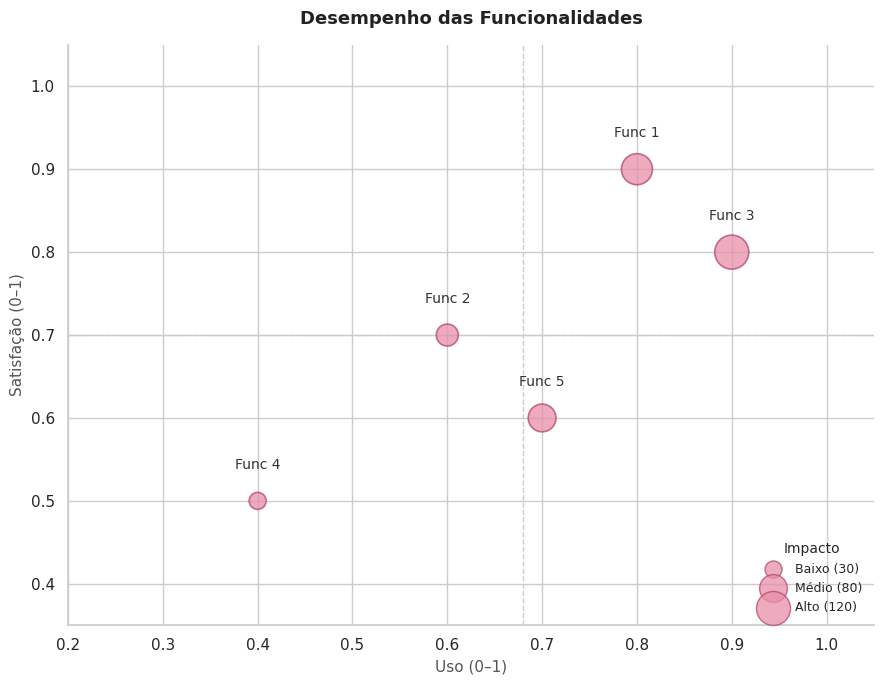

In [30]:
# 1. Problemas identificados:
#    a) Gestalt (similaridade): cores aleatórias em cada bolha não comunicam nada e
#       criam a falsa impressão de que a cor codifica alguma informação
#    b) Cleveland-McGill: área de bolha é uma das codificações menos precisas
#       perceptivamente, e sem legenda de escala é impossível saber o que o tamanho
#       representa numericamente
#    c) Tufte (Chartjunk): grade pontilhada + cores aleatórias + rótulos no centro
#       das bolhas competindo com os dados criam poluição visual desnecessária

# 2. Código refatorado:

fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(df_funcionalidades['Uso'], df_funcionalidades['Satisfacao'],
                     s=df_funcionalidades['Impacto'] * 5,
                     color='#e88fa8', edgecolor='#b5446e', linewidth=1.2,
                     alpha=0.75, zorder=3)

for _, row in df_funcionalidades.iterrows():
    ax.text(row['Uso'], row['Satisfacao'] + 0.035,
            row['Funcionalidade'], fontsize=10,
            ha='center', va='bottom', color='#333333')

for impacto, label in zip([30, 80, 120], ['Baixo (30)', 'Médio (80)', 'Alto (120)']):
    ax.scatter([], [], s=impacto * 5, color='#e88fa8',
               edgecolor='#b5446e', alpha=0.75, label=label)
ax.legend(title='Impacto', frameon=False, fontsize=9, title_fontsize=10,
          loc='lower right')

ax.axvline(df_funcionalidades['Uso'].mean(), color='#cccccc', linewidth=1, linestyle='--', zorder=1)
ax.axhline(df_funcionalidades['Satisfacao'].mean(), color='#cccccc', linewidth=1, linestyle='--', zorder=1)

ax.set_xlim(0.2, 1.05)
ax.set_ylim(0.35, 1.05)
ax.set_title('Desempenho das Funcionalidades',
             fontsize=13, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel('Uso (0–1)', fontsize=11, color='#555555')
ax.set_ylabel('Satisfação (0–1)', fontsize=11, color='#555555')

sns.despine(ax=ax)
plt.tight_layout()
plt.show()